## PSKF: 1-D Free-Fall

### Discrete-Time 1-D Free-Fall Model

As before, with time step $Δt = 1$s, state  
$$
x_k = \begin{bmatrix} z_k \\ v_k \\ g_k \end{bmatrix},
$$  
dynamics  
$$
x_{k+1} = F\,x_k,
\quad
F = \begin{bmatrix}
1 & Δt & \tfrac12\,Δt^2 \\[4pt]
0 & 1  & Δt \\[4pt]
0 & 0  & 1
\end{bmatrix},
$$  
and measurement  
$$
y_k = H\,x_k + v_k,
\quad
H = [\,1\;\;0\;\;0\,].
$$

---

### Standard EKF Update

Compute the full-EKF predicted and updated estimates:  
$$
\begin{aligned}
\hat x^-_k &\to \hat x^+_k = \hat x^-_k + K_k\bigl(y_k - H\,\hat x^-_k\bigr),\\[4pt]
P^-_k     &\to P^+_k = (I - K_kH)\,P^-_k\,(I - K_kH)^T + K_k\,R\,K_k^T.
\end{aligned}
$$

---

### Fixed-Weight Partial Update (FPSKF) 

Introduce a constant partial-update weight $β∈[0,1]$ applied to the nuisance state $g$, and define $γ = 1 - β$.  Denote by $\hat x_{i,\mathrm{EKF}}^+$ and $P_{ij,\mathrm{EKF}}^+$ the full-EKF updated state and covariance.  The fixed-weight PSKF then blends prior and full-update values for the $i$th state:

$$
\boxed{
\begin{aligned}
\hat x_i^+ &= γ\,\hat x_i^- + (1-γ)\,\hat x_{i,\mathrm{EKF}}^+,\\[6pt]
P_{ij}^+  &= γ^2\,P_{ij}^- + \bigl(1-γ^2\bigr)\,P_{ij,\mathrm{EKF}}^+.
\end{aligned}
}
$$

- $β=1$ ($γ=0$) → full EKF on that state.  
- $β=0$ ($γ=1$) → no update (classic SKF) on that state.  
- $0<β<1$ → partial update.

---

### Generalized PSKF

For a vector $β=[β_1,β_2,⋯,β_n]^T$ and $γ_i=1-β_i$, for all $i,j$:

$$
\boxed{
\begin{aligned}
\hat x_i^+ &= γ_i\,\hat x_i^- + (1-γ_i)\,\hat x_{i,\mathrm{EKF}}^+,\\[4pt]
P_{ij}^+  &= γ_i\,γ_j\,P_{ij}^- + \bigl(1-γ_i\,γ_j\bigr)\,P_{ij,\mathrm{EKF}}^+.
\end{aligned}
}
$$

---

In [ ]:
# Discrete-time model
dt = 1.0
F = np.array([[1, dt, 0.5*dt**2],
              [0, 1,        dt],
              [0, 0,         1]])
H = lambda x,u: np.array([[1.0, 0.0, 0.0]])
h = lambda x,u: np.array([x[0]])

# Covariances
Q = np.diag([0.1, 0.1, 0.01])
R = np.array([[1.0]])

# Simulate true motion (g=9.8)
N = 50
g_true = 9.8
x_true = np.zeros((N,3))
x_true[0] = [0.0, 0.0, g_true]
for k in range(1, N):
    x_true[k] = F @ x_true[k-1]

y = x_true[:,0] + np.random.randn(N)*np.sqrt(R[0,0])
y_df = pd.DataFrame(y, columns=['z'])

# Initial estimate 
g_est0 = 5
x0 = pd.Series([0.0, 0.0, g_est0], index=['z','v','g'])
P0 = np.diag([1.0, 1.0, (g_est0 - g_true)**2])

# Filters
ekf = pk.EKF(f=lambda x,
             u: F@x, 
             h=h, 
             Q=Q, 
             R=R, 
             dt=dt,
             system_type=pk.SystemType.DISCRETE_TIME_INVARIANT)
skf = pk.SKF(f=lambda x,
            u: F@x, 
            h=h, 
            Q=Q,
            R=R,
            dt=dt,
            system_type=pk.SystemType.DISCRETE_TIME_INVARIANT,
            update_mask=np.array([True, True, False]))
pskf = pk.PSKF(f=lambda x,
            u: F@x,
            h=h,
            Q=Q,
            R=R,
            dt=dt,
            system_type=pk.SystemType.DISCRETE_TIME_INVARIANT,
            beta=np.array([1.0, 0.8, 0.5]))  # 50% update on g


# Run filters
x_est_ekf, P_est_ekf  = ekf.run(x0, P0, y_df, F, H)
x_est_skf,  P_est_skf = skf.run(x0, P0, y_df, F, H)
x_est_pskf, P_est_pskf = pskf.run(x0, P0, y_df, F, H)

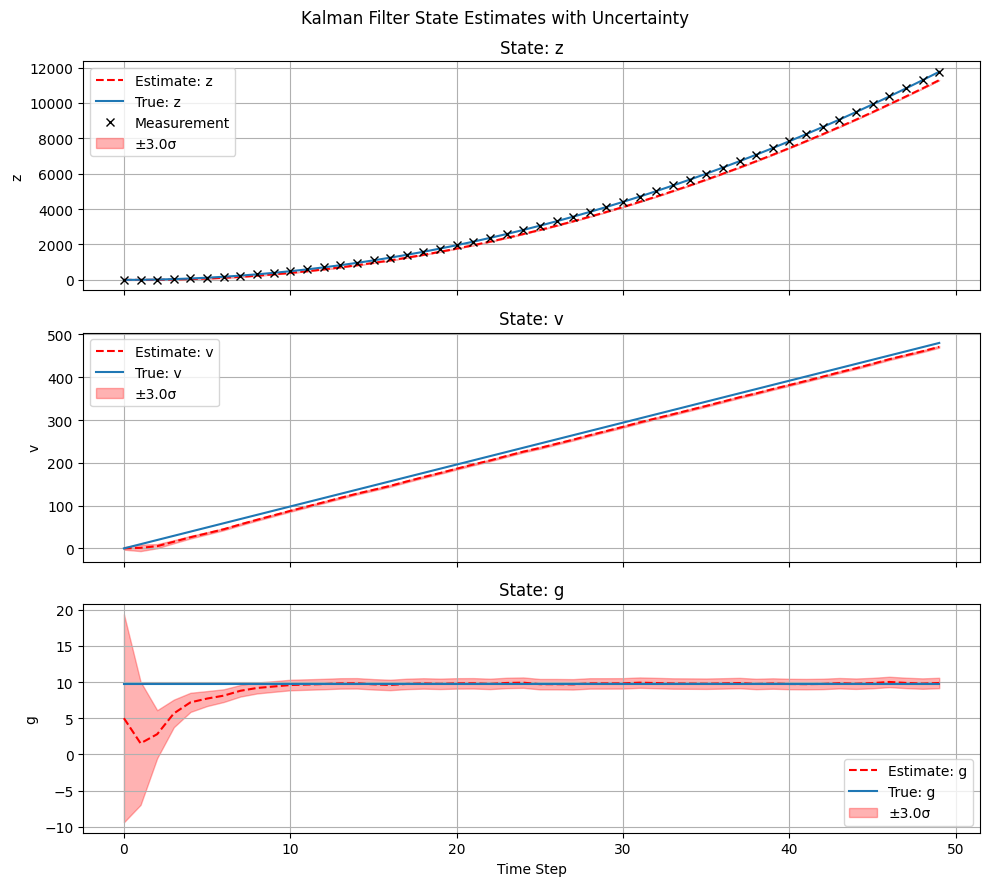

In [ ]:
# Truncate to N
x_est_ekf  = x_est_ekf.iloc[:N]
P_est_ekf  = P_est_ekf[:N]
ekf.plot_kf_predictions(
    x_est_ekf, P_est_ekf,
    x_true_df=pd.DataFrame(x_true, columns=['z','v','g']),
    y_df=y_df
)

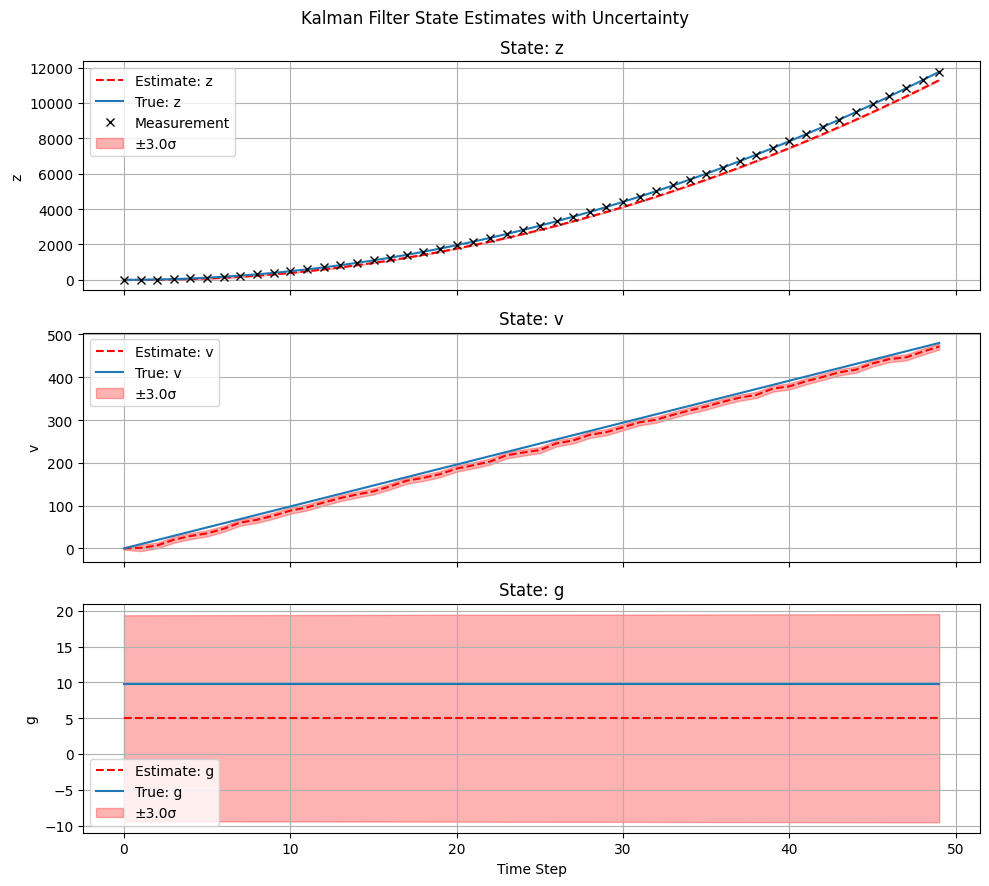

In [ ]:
x_est_skf  = x_est_skf.iloc[:N]
P_est_skf  = P_est_skf[:N]

skf.plot_kf_predictions(
    x_est_skf, P_est_skf,
    x_true_df=pd.DataFrame(x_true, columns=['z','v','g']),
    y_df=y_df
)

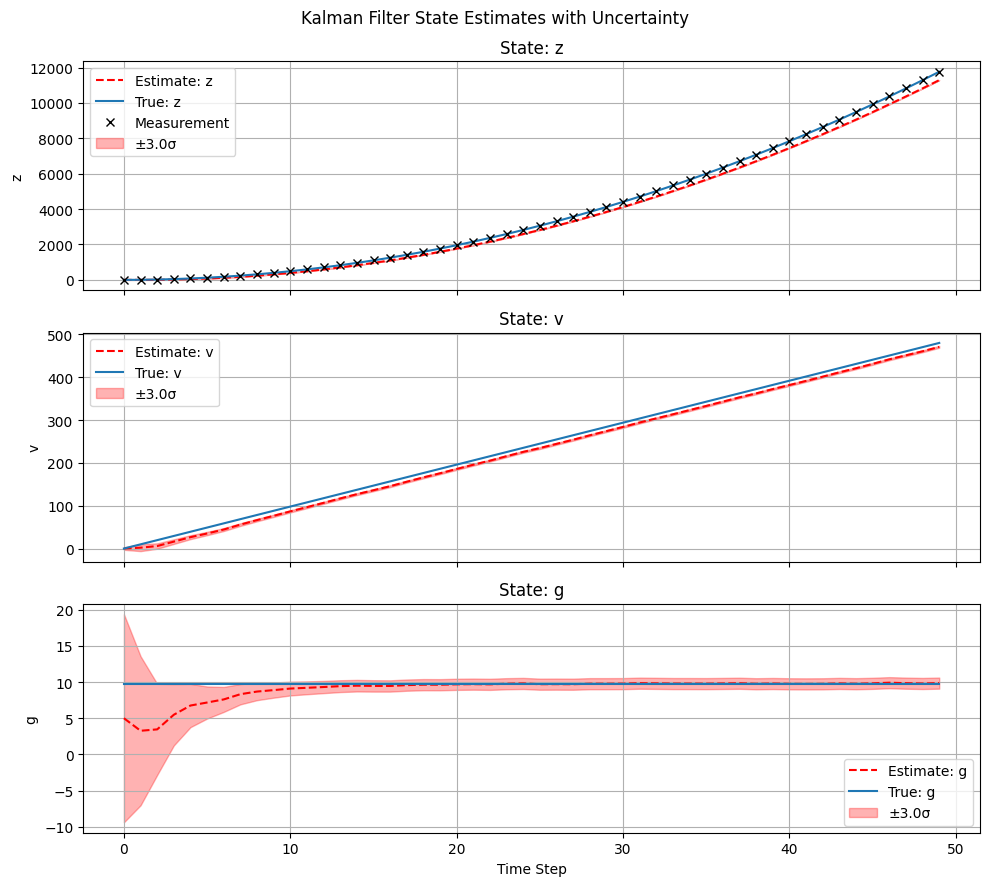

In [ ]:
x_est_pskf = x_est_pskf.iloc[:N]
P_est_pskf = P_est_pskf[:N]

pskf.plot_kf_predictions(
    x_est_pskf, P_est_pskf,
    x_true_df=pd.DataFrame(x_true, columns=['z','v','g']),
    y_df=y_df
)

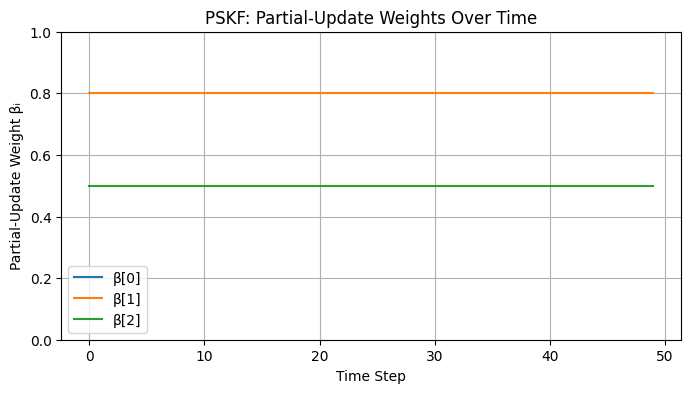

In [ ]:
pskf.plot_beta(x_est_df=x_est_pskf)